# Employee Attrition Analysis and Prediction
## Table of Contents

1. Project Overview

2. Load Dataset

3. Data Cleaning

4. Exploratory Data Analysis

5. Machine Learning

6. Model Evaluation

7. Business Recommendations

8. Conclusion

## 1. Project Overview

### Objective

Employee attrition is one of the major challenges faced by organizations, as high turnover can increase recruitment costs, reduce productivity, and negatively impact overall business performance.

The objective of this project is to analyze employee attrition using HR analytics data, identify the key factors influencing employees' decisions to leave the company, build a machine learning model to predict employee attrition, and provide business recommendations that can help improve employee retention.

---

### Business Problem

Organizations invest significant time and resources in recruiting and training employees. However, losing experienced employees can result in financial losses, decreased productivity, and operational challenges.

This project aims to explore employee data to understand why employees leave the company and how data-driven insights can support better human resource decisions.

---

### Business Questions

This project aims to answer the following questions:

1. What is the overall employee attrition rate?
2. Which departments experience the highest attrition?
3. Does overtime increase the likelihood of employee attrition?
4. How does monthly income affect employee attrition?
5. Does job satisfaction influence employees' decisions to leave?
6. Which employee characteristics are most associated with attrition?
7. Can machine learning accurately predict employee attrition?

---

### Dataset Description

**Source:** Kaggle

**Dataset Name:** IBM HR Analytics Employee Attrition & Performance

**Domain:** Human Resources Analytics

**Target Variable:** Attrition

The dataset contains demographic, job-related, and performance-related information for employees. It is designed to help analyze employee turnover and identify the factors that contribute to attrition.

# Chapter 2: Import Libraries & Load Dataset

In this chapter, we import the required Python libraries and load the dataset. We then perform an initial inspection to understand the dataset structure before proceeding to the data cleaning stage.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load the dataset into a Pandas DataFrame
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [ ]:
# Display the first five rows of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# Display dataset information (data types, non-null values, memory usage)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
# Display the number of rows and columns
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1470
Columns: 35


In [8]:
# Generate descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


# Chapter 3: Data Cleaning & Preparation

In this chapter, we inspect the dataset for missing values, duplicate records, incorrect data types, and unnecessary columns. The goal is to ensure that the dataset is clean and ready for exploratory data analysis.

In [9]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

print("-" * 50)

# Check for duplicate records
print("Duplicate Rows:")
print(df.duplicated().sum())

print("-" * 50)

# Display data types
print("Data Types:")
print(df.dtypes)

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

In [10]:
# Display unique values for categorical columns
for col in df.select_dtypes(include='object'):
    print(f"\n{col}")
    print(df[col].unique())


Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department
['Sales' 'Research & Development' 'Human Resources']

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender
['Female' 'Male']

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus
['Single' 'Married' 'Divorced']

Over18
['Y']

OverTime
['Yes' 'No']


In [11]:
# Remove unnecessary columns
df.drop(columns=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
], inplace=True)

# Verify dataset shape after cleaning
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1470
Columns: 31


## Cleaning Summary

- No missing values were found in the dataset.
- No duplicate records were detected.
- All categorical values are consistent.
- Four unnecessary columns were removed.
- The dataset is clean and ready for exploratory data analysis.

# Chapter 4: Exploratory Data Analysis (EDA)

In this chapter, we explore the employee dataset to identify patterns, trends, and relationships related to employee attrition. The analysis aims to answer the business questions defined earlier by using statistical summaries and visualizations. Each analysis focuses on understanding the factors that may influence employee turnover and provides insights to support data-driven business decisions.

## 4.1 Employee Attrition Overview

### Business Question

**What is the overall employee attrition rate?**

To begin the analysis, we first need to understand the overall employee attrition rate. This provides a clear picture of the size of the problem before exploring the factors that may influence employee turnover.


Attrition
No     1233
Yes     237
Name: count, dtype: int64


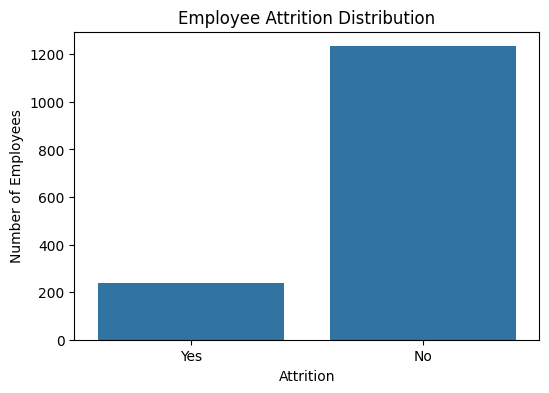

In [12]:
# Count the number of employees in each attrition category
attrition_counts = df['Attrition'].value_counts()

# Display the counts
print(attrition_counts)

# Visualize the distribution of employee attrition
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition')

# Add a clear title and axis labels
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

# Display the chart
plt.show()

In [13]:
# Calculate the percentage of employees who stayed and left
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100

# Display the percentage
print(attrition_percentage.round(2))

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


### Observation

The dataset contains 1,470 employees, of which 237 employees (16.12%) left the company, while 1,233 employees (83.88%) remained. This indicates that employee attrition exists but affects a relatively small proportion of the workforce.


## 4.2 Department Analysis

### Business Question

**Which department has the highest employee attrition?**

After understanding the overall attrition rate, the next step is to identify which department experiences the highest employee attrition. This helps organizations determine where employee turnover is most common and where retention strategies should be prioritized.


Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


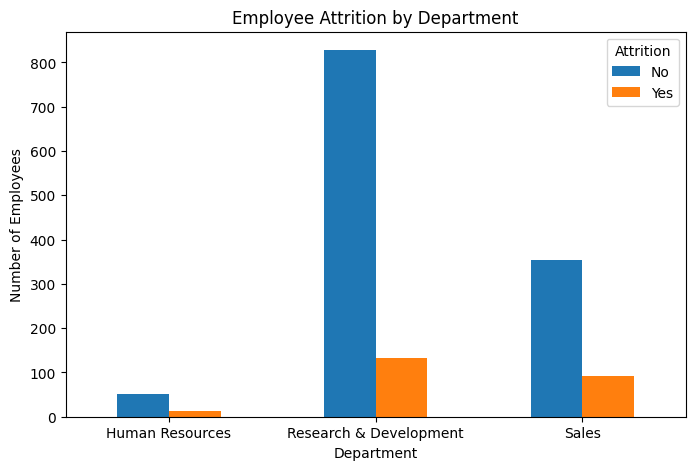

In [14]:
# Count employee attrition by department
department_attrition = pd.crosstab(df['Department'], df['Attrition'])

# Display the result
print(department_attrition)

# Visualize employee attrition across departments
department_attrition.plot(kind='bar', figsize=(8,5))

# Add chart title and labels
plt.title('Employee Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [15]:
# Calculate the attrition percentage for each department
department_percentage = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

# Display the attrition percentage
print(department_percentage.round(2))

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


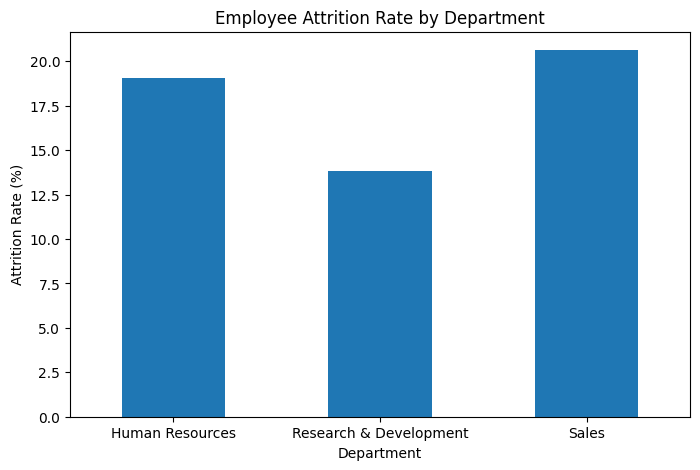

In [16]:
# Visualize the attrition percentage by department
department_percentage['Yes'].plot(kind='bar', figsize=(8,5))

# Add chart title and labels
plt.title('Employee Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

# Display the chart
plt.show()

### Observation

Although the Research & Development department has the highest number of employees leaving the company, the Sales department has the highest attrition rate at **20.63%**, followed by Human Resources (**19.05%**). This indicates that employees in the Sales department are more likely to leave the company than employees in other departments.

## 4.3 Overtime Analysis

### Business Question

**Does overtime increase the likelihood of employee attrition?**

Overtime can increase employee stress, reduce work-life balance, and negatively affect job satisfaction. In this section, we examine whether employees who work overtime are more likely to leave the company.

In [17]:
# Count employee attrition based on overtime status
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'])

# Display the result
print(overtime_attrition)

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


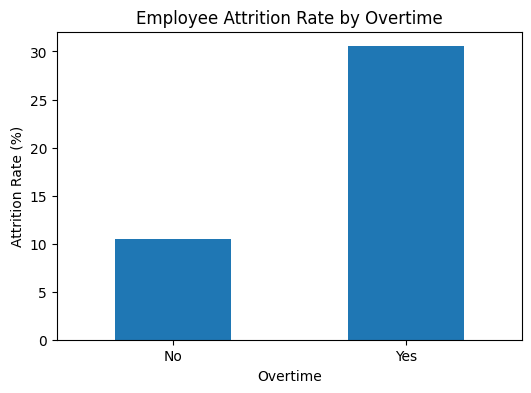

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the attrition percentage for each overtime status
overtime_percentage = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

# Visualize the attrition rate based on overtime status
overtime_percentage['Yes'].plot(kind='bar', figsize=(6,4))

# Add chart title and labels
plt.title('Employee Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

# Display the chart
plt.show()

### Observation

Employees who work overtime have a significantly higher attrition rate than those who do not. Approximately **30%** of employees who work overtime left the company, compared to only **10%** of employees who do not work overtime. This suggests that overtime may be a strong factor associated with employee attrition.

## 4.4 Monthly Income Analysis

### Business Question

**Does monthly income influence employee attrition?**

Salary is one of the most important factors affecting employee retention. In this section, we compare the monthly income of employees who stayed with those who left the company to determine whether income may be associated with employee attrition.

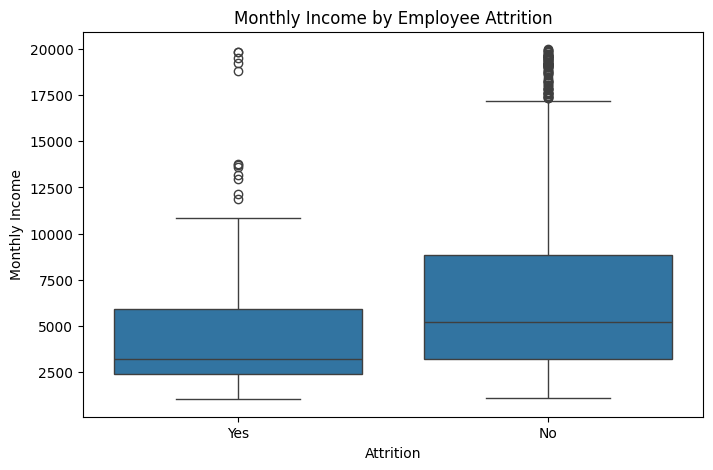

In [22]:
# Compare monthly income between employees who stayed and those who left
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')

# Add chart title and labels
plt.title('Monthly Income by Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

# Display the chart
plt.show()

In [23]:
# Calculate summary statistics for monthly income
income_summary = df.groupby('Attrition')['MonthlyIncome'].describe()

# Display the summary statistics
print(income_summary.round(2))

            count     mean      std     min     25%     50%     75%      max
Attrition                                                                   
No         1233.0  6832.74  4818.21  1051.0  3211.0  5204.0  8834.0  19999.0
Yes         237.0  4787.09  3640.21  1009.0  2373.0  3202.0  5916.0  19859.0


### Observation

Employees who left the company generally earned lower monthly salaries than those who stayed. The median and average monthly income are noticeably lower for employees who left, suggesting that lower income may be associated with a higher likelihood of employee attrition.

## 4.5 Job Satisfaction Analysis

### Business Question

**Does job satisfaction influence employee attrition?**

Job satisfaction is an important factor in employee retention. In this section, we examine whether employees with lower job satisfaction are more likely to leave the company.

In [24]:
# Count employee attrition for each job satisfaction level
job_satisfaction = pd.crosstab(df['JobSatisfaction'], df['Attrition'])

# Display the result
print(job_satisfaction)

Attrition         No  Yes
JobSatisfaction          
1                223   66
2                234   46
3                369   73
4                407   52


In [25]:
# Calculate the attrition percentage for each job satisfaction level
job_satisfaction_percentage = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

# Display the percentage
print(job_satisfaction_percentage.round(2))

Attrition           No    Yes
JobSatisfaction              
1                77.16  22.84
2                83.57  16.43
3                83.48  16.52
4                88.67  11.33


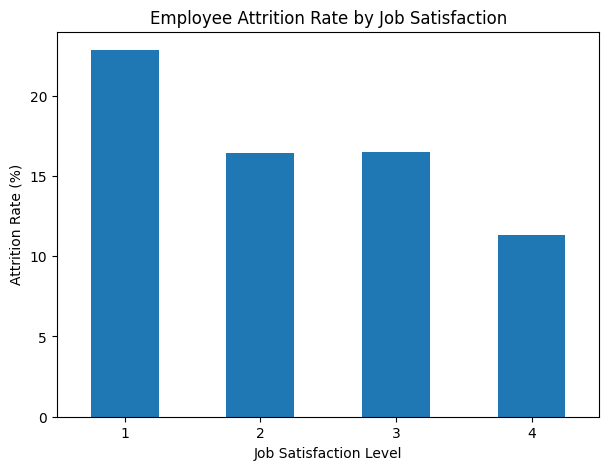

In [26]:
# Visualize the attrition rate by job satisfaction level
job_satisfaction_percentage['Yes'].plot(kind='bar', figsize=(7,5))

# Add chart title and labels
plt.title('Employee Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

# Display the chart
plt.show()

### Observation

Employees with lower job satisfaction are more likely to leave the company. Employees with a job satisfaction level of **1** have the highest attrition rate (**22.84%**), while employees with the highest satisfaction level (**4**) have the lowest attrition rate (**11.33%**). This suggests that higher job satisfaction is associated with better employee retention.

## 4.6 Work-Life Balance Analysis

### Business Question

**Does work-life balance influence employee attrition?**

Maintaining a healthy work-life balance is essential for employee well-being and retention. In this section, we examine whether employees with lower work-life balance are more likely to leave the company.

In [27]:
# Count employee attrition for each work-life balance level
worklife_attrition = pd.crosstab(df['WorkLifeBalance'], df['Attrition'])

# Display the result
print(worklife_attrition)

Attrition         No  Yes
WorkLifeBalance          
1                 55   25
2                286   58
3                766  127
4                126   27


In [28]:
# Calculate the attrition percentage for each work-life balance level
worklife_percentage = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

# Display the percentage
print(worklife_percentage.round(2))

Attrition           No    Yes
WorkLifeBalance              
1                68.75  31.25
2                83.14  16.86
3                85.78  14.22
4                82.35  17.65


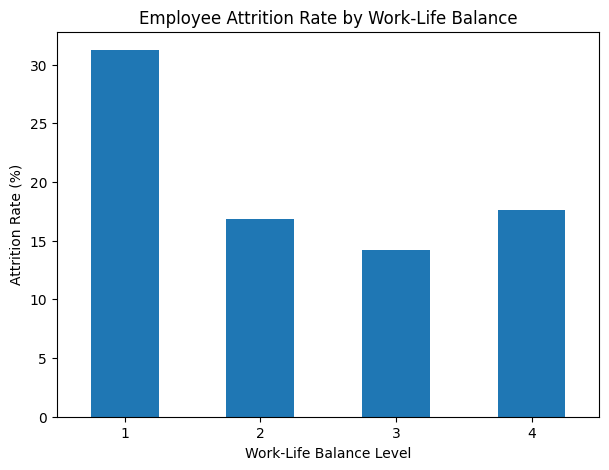

In [29]:
# Visualize the attrition rate by work-life balance
worklife_percentage['Yes'].plot(kind='bar', figsize=(7,5))

# Add chart title and labels
plt.title('Employee Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

# Display the chart
plt.show()

### Observation

Employees with the lowest work-life balance level (**1**) have the highest attrition rate at **31.25%**. Although the attrition rate does not decrease consistently across all levels, employees with better work-life balance generally show lower attrition rates. This suggests that poor work-life balance may be associated with a higher likelihood of employee attrition.

## 4.7 Age Analysis

### Business Question

**Does employee age influence employee attrition?**

Employee age may influence career decisions, job expectations, and turnover behavior. In this section, we compare the age distribution of employees who stayed with those who left the company to determine whether age is associated with employee attrition.

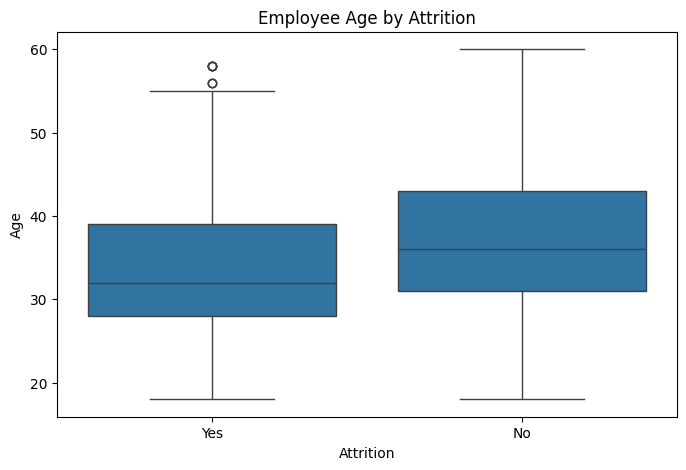

In [30]:
# Compare employee age between employees who stayed and those who left
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='Age')

# Add chart title and labels
plt.title('Employee Age by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Age')

# Display the chart
plt.show()

In [31]:
# Calculate summary statistics for employee age
age_summary = df.groupby('Attrition')['Age'].describe()

# Display the summary statistics
print(age_summary.round(2))

            count   mean   std   min   25%   50%   75%   max
Attrition                                                   
No         1233.0  37.56  8.89  18.0  31.0  36.0  43.0  60.0
Yes         237.0  33.61  9.69  18.0  28.0  32.0  39.0  58.0


### Observation

Employees who left the company are generally younger than those who stayed. The average age of employees who left is **33.61 years**, compared to **37.56 years** for employees who remained. This suggests that younger employees may be more likely to leave the company.

## 4.8 Years at Company Analysis

### Business Question

**Does the number of years at the company influence employee attrition?**

Employees who recently joined a company may have different turnover behavior than long-term employees. In this section, we compare the years employees have spent at the company to determine whether experience within the company is associated with employee attrition.

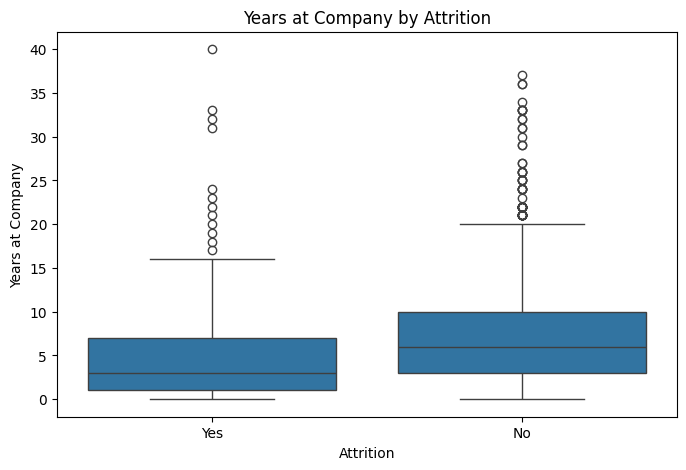

In [32]:
# Compare years at company between employees who stayed and those who left
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')

# Add chart title and labels
plt.title('Years at Company by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')

# Display the chart
plt.show()

In [33]:
# Calculate summary statistics for years at company
years_summary = df.groupby('Attrition')['YearsAtCompany'].describe()

# Display the summary statistics
print(years_summary.round(2))

            count  mean   std  min  25%  50%   75%   max
Attrition                                               
No         1233.0  7.37  6.10  0.0  3.0  6.0  10.0  37.0
Yes         237.0  5.13  5.95  0.0  1.0  3.0   7.0  40.0


### Observation

Employees who left the company generally spent fewer years at the company than those who stayed. The average tenure of employees who left is **5.13 years**, compared to **7.37 years** for employees who remained. This suggests that employees with shorter tenure are more likely to leave the company.

## 4.9 Correlation Analysis

### Business Question

**Which numerical features are most strongly related to each other?**

Correlation analysis helps identify relationships between numerical variables. Although correlation does not imply causation, it provides useful insights that support exploratory data analysis and helps identify features that may influence employee attrition.

In [34]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
correlation_matrix.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999


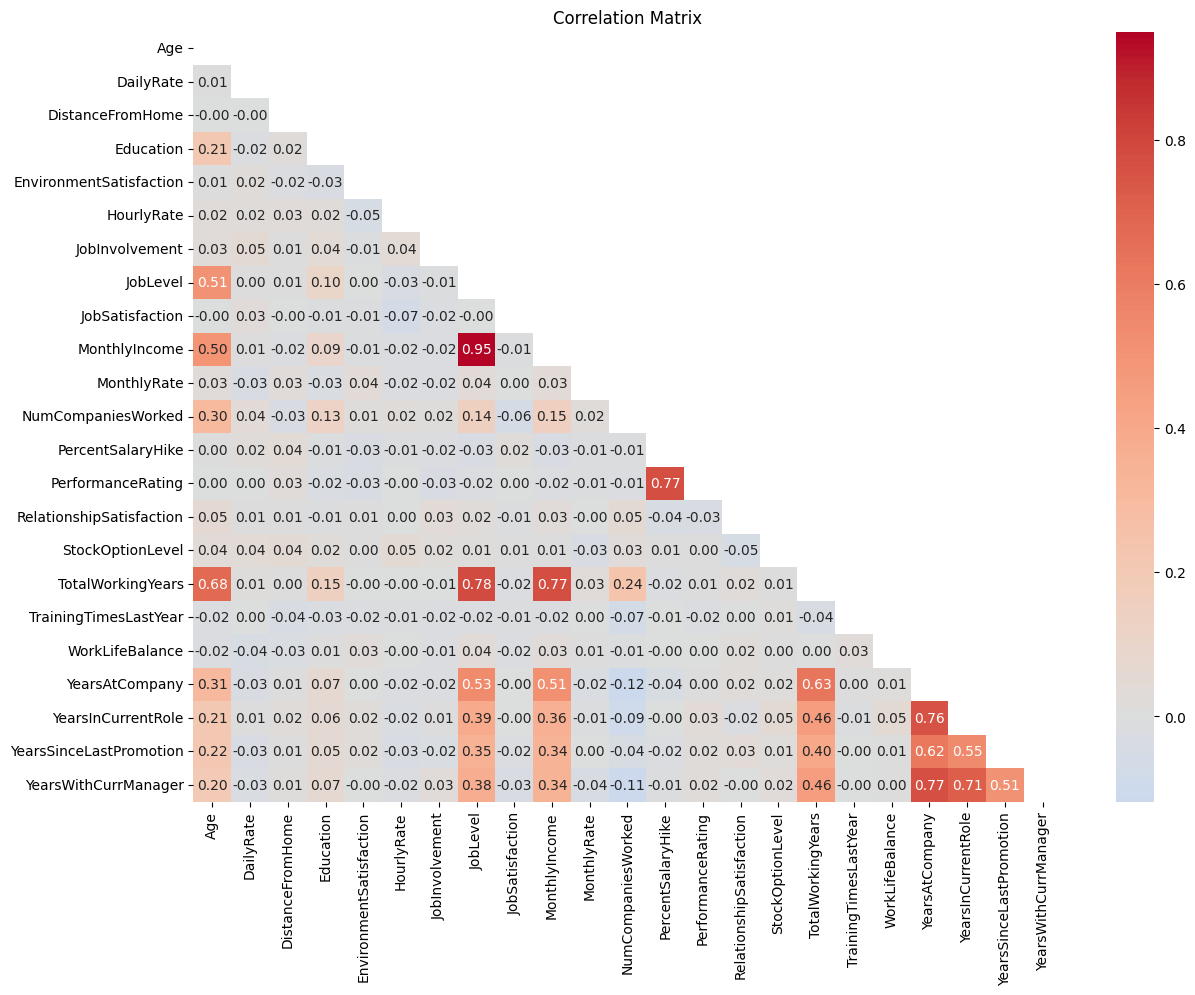

In [36]:
# Display only the lower triangle of the correlation matrix
plt.figure(figsize=(14,10))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

### Observation

The correlation analysis shows several strong relationships between numerical variables. Monthly income has a very strong positive correlation with job level (0.95), while total working years are strongly correlated with age (0.68). Additionally, years at the company are strongly associated with years in the current role and years with the current manager. These relationships are expected and help validate the consistency of the dataset.

# 5. Machine Learning

### Goal

The objective of this section is to build a machine learning model that predicts whether an employee is likely to leave the company based on demographic, work-related, and satisfaction features.

The model will help demonstrate how predictive analytics can support human resource decision-making and employee retention strategies.

## 5.1 Data Preparation

### Why is data preparation important?

Machine learning algorithms require numerical input. Therefore, categorical variables must be converted into numerical values before training the model.

In [37]:
# Create a copy of the dataset for machine learning
ml_df = df.copy()

# Display the first five rows
ml_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [38]:
# Display categorical columns
categorical_columns = ml_df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')


In [39]:
# Convert Attrition into numerical values
ml_df['Attrition'] = ml_df['Attrition'].map({
    'No':0,
    'Yes':1
})

# Verify the conversion
ml_df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


## 5.2 Encoding Categorical Variables

### Why is encoding necessary?

Machine learning models cannot work with text values. Therefore, categorical variables are converted into numerical features using One-Hot Encoding before training the model.

In [40]:
# Convert categorical variables into numerical variables
ml_df = pd.get_dummies(ml_df, drop_first=True)

# Display the first five rows
ml_df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [41]:
# Check the new dataset dimensions
print("Dataset Shape:", ml_df.shape)

Dataset Shape: (1470, 45)


In [42]:
# Verify that no categorical columns remain
print(ml_df.select_dtypes(include='object').columns)

Index([], dtype='object')


## 5.3 Feature Selection and Train-Test Split

### Why do we split the data?

Machine learning models should be evaluated on unseen data. Therefore, the dataset is divided into a training set for learning patterns and a testing set for evaluating the model's performance.

In [43]:
# Separate features and target variable
X = ml_df.drop('Attrition', axis=1)
y = ml_df['Attrition']

# Display dataset dimensions
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 44)
Target Shape: (1470,)


In [44]:
# Import train-test split
from sklearn.model_selection import train_test_split

In [45]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the dataset sizes
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


## 5.4 Logistic Regression Model

### Why Logistic Regression?

Logistic Regression is one of the most common algorithms for binary classification problems. Since employee attrition has two possible outcomes (Stayed or Left), Logistic Regression provides a simple and effective baseline model for prediction.

In [46]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [47]:
# Create and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [48]:
# Predict employee attrition on the testing set
y_pred = model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


## 6. Model Evaluation

### Model Performance Summary

After training the Logistic Regression model, its performance was evaluated using multiple classification metrics. While the model achieved a relatively high overall accuracy, the remaining metrics indicate that predicting employee attrition remains a challenging task due to the imbalance in the dataset. Therefore, accuracy alone is not sufficient to evaluate the model's effectiveness.

In [49]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [50]:
# Calculate model evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the results
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.850
Precision: 0.308
Recall   : 0.103
F1 Score : 0.154


### Observation

The Logistic Regression model achieved an **accuracy of 85.0%**, indicating that most predictions were correct overall. However, the model showed **low precision (30.8%)** and **very low recall (10.3%)**, meaning it struggled to correctly identify employees who actually left the company. This is mainly due to the class imbalance in the dataset, where most employees did not leave the company. Therefore, the model can be considered a useful baseline model, but its ability to detect employee attrition is limited.

# 7. Business Recommendations

### Purpose

Based on the insights discovered during the exploratory data analysis and the machine learning model, the following recommendations are proposed to help reduce employee attrition and improve employee retention.

### 1. Reduce Excessive Overtime

Employees who frequently worked overtime showed a noticeably higher attrition rate. The company should monitor overtime hours and encourage a healthier work-life balance.

### 2. Improve Employee Satisfaction

Employees with lower job satisfaction were more likely to leave the company. Regular employee feedback surveys and career development programs may help improve satisfaction levels.

### 3. Support New Employees

Employees with fewer years at the company were more likely to leave. A stronger onboarding process and mentorship programs could improve employee retention during the first years of employment.


### 4. Review Compensation Strategies

Employees with lower monthly income showed a higher tendency to leave. Reviewing salary structures and reward programs may help increase employee retention.


### 5. Monitor Employee Well-being

Poor work-life balance was associated with higher employee attrition. Organizations should promote employee well-being through flexible work policies and wellness initiatives.

# 8. Conclusion

This project analyzed employee attrition using Python, focusing on data cleaning, exploratory data analysis, and predictive modeling.

The analysis identified several factors associated with employee attrition, including overtime, monthly income, job satisfaction, work-life balance, employee age, and years at the company. These insights provide valuable information that can support human resource strategies and improve employee retention.

A Logistic Regression model was developed as a baseline machine learning model to predict employee attrition. While the model achieved good overall accuracy, its performance was limited by the imbalance of the dataset, highlighting opportunities for future improvements.

Overall, this project demonstrates a complete data analytics workflow, from understanding the business problem to generating actionable insights and building a predictive model.